# 🎓 1st Project — **1st Delivery**


### Teacher
- Cristian Camilo Zapata Zuluaga

### Students
- Roi Jared Flores Garza Stone
- Ivan Morales

December 2nd , 2025, ITESO

# Introduction

In the recent years, wellness has shifted from a lifestyle trend to a global priority. According to TIME magazine, younger generations are drinking less alcohol and increasingly adopting health conscious behaviors, such as reducing smoking and increasing physical activity,As noted by Solcyre Burga "A 2023 survey from Gallup found that the share of adults under age 35 who say they ever drink dropped ten percentage points in two decades, to 62% in 2021-2023 from 72% in 2001-2003".

Within this context, sleep quality emerges as a critical metric of health in general, in this project we aim to analyze the relationship of the factors we mentioned befeore, as well as to predict and understand the impact of caffeine on sleep quality.

Beyond the statistical analysis, research and data wrangling, this project will also serve as a comprehensive implementation of a Machine Learning Operation Pipeline (MLOps), it demonstrates the complete cycle from the EDA to the deployment of an app in Streamlit ready to predict the Sleep Quality.

# Records

The relationship between coffee intake and sleep patterns has been extensively documented in medical papers. Conventional or people's wisdom suggest a direct negative correlation, implying tha increased caffeine consumption leads to bad sleep patterns, studies may contradict us.

A particular relevant study by Sedat Arslan digged deeper into this dynamic relationship, their research concluded the following, *Daily caffeine consumption among healthcare professionals may have a positive effect on sleep duration, but does not have a significant impact on overall sleep quality. (Arslan et al., 2025)*

This extraordinary finding challenges the common conception about this relationship, coffe ruins sleep or if you drink a lot of coffee you won't be able to sleep well, the research suggest that the relationship is well more complex, factors like sleep duration might be preserved or even extended in certain contexts, despite caffeine intake. This distinction is crucial for our project. By implementing Machine Learning models, we aim to go beyond simple linear correlations and detect these non-obvious patterns within our dataset.

# Objective

To develop and End-To-End Machine Learning project capable of predicting an individual's **Sleep Quality** based on their daily habits, with a specific focus on **Caffeine Consumption**

## Particular Objectives

- To quantify the effects of the different variables such as the consumption of alcohol and cigarrettes in the sleeping quality of an individual.

- To implement data engineering and analysis techniques while working with GitHub, Mlfow, Databricks, Streamlit and Docker.

- To comprehend, as a coffee drinker how caffeine intake affects sleeping and stress levels and how much is enough when talking about caffeine ingestion.

# Problem Statement

Sleep is a fundamental pillar of human health, essential for physical recovery, memory consolidation, and emotional regulation. However, sleep quality is highly variable and affected by a complex interplay of personal, environmental, and behavioral factors.
Poor sleep quality is not merely an inconvenience; it is a significant risk factor for the development of chronic diseases, mood disorders, and an overall reduction in productivity and quality of life. Understanding the factors that influence sleep is crucial for public health and individual well-being.

While there is a general awareness that factors such as stress or caffeine consumption affect sleep, the specific relationships and their combined predictive power are unclear.
The central objective of this project is to go beyond simple correlation to develop a machine learning model capable of predicting an individual's sleep quality (classified as Poor, Fair, Good, or Excellent) based on a set of measurable features.

This project adresses the challenge of quantifying these relationships by framing the task as a **Supervised Multiclass Classification Problem**.

The objective is to develop a Machine Learning model capable of mapping a set of input features $X$ such as caffeine intake, physical activity hours, age, stress levels, gender amongst others, to a discrete target variable $Y$, the individual's sleep quality, categorized as:

- Poor
- Fair
- Good 
- Excellent

# EDA

For full EDA see: notebooks/_01_eda_inicial.ipynb

We took a firts glance in the data to understand better how our data behaves.

Our dataset is composed of 10,000 instances with 15 variables.
- 0   ID                       10000 non-null  int64  
- 1   Age                      10000 non-null  int64  
- 2   Gender                   10000 non-null  object 
- 3   Country                  10000 non-null  object 
- 4   Coffee_Intake            10000 non-null  float64
- 5   Caffeine_mg              10000 non-null  float64
- 6   Sleep_Hours              10000 non-null  float64
- 7   Sleep_Quality            10000 non-null  object 
- 8   BMI                      10000 non-null  float64
- 9   Heart_Rate               10000 non-null  int64  
- 10  Stress_Level             10000 non-null  object 
- 11  Physical_Activity_Hours  10000 non-null  float64
- 12  Health_Issues            4059 non-null   object 
- 13  Occupation               10000 non-null  object 
- 14  Smoking                  10000 non-null  int64  
- 15  Alcohol_Consumption      10000 non-null  int64 

The info is pretty much complete, no Null Values, the only column with missing values is "Healt_Issues" with 5941 NaN values but we interpreted them as an individual with no Healt Issues at all.

In this dataset we have are:
>- 5001 woman (50.01%)
>- 4773 man (47.73%)
>- 226 other (2.26%)

This is slightly different than the real world but normal, according to the *Ined - Institut National d’Études Démographiques* 

*"Of every 1,000 people, 504 are men (50.4%) and 496 are women (49.6%)" (Are There More Men or More Women in the World?, 2020)*

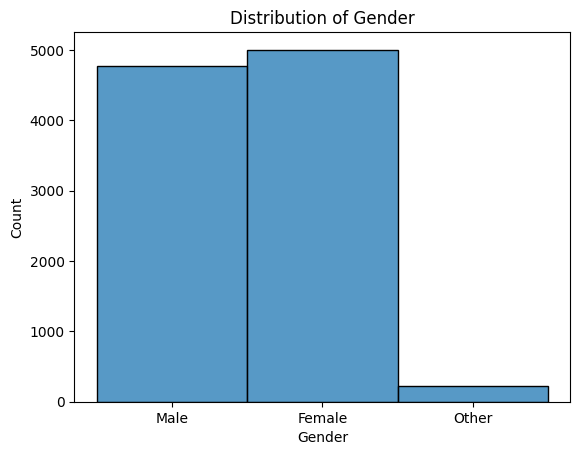\

Most of the individuals in the dataset have a Good sleep quality.

>- Excellent sleep quality 13.52%
>- Good sleep quality 56.37%
>- Fair sleep quality 20.50%
>- Poor sleep quality 9.61%

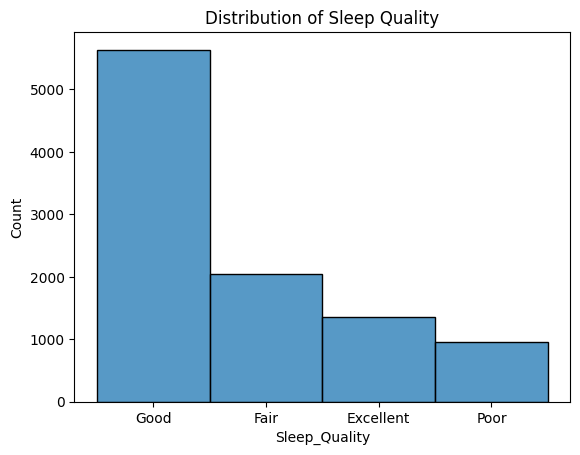

The difference in between the health issues in the population of this dataset is really noticeable, most of them present mild health isues and barely any of them present severe health isues, we could say is a healthy population.

Based on the last proposition we can infer than the missing values on this column may not be missing at all but can be interpreted as no health issues at all.

With the following idea the percentages of health issues would be the next ones.

>- No health issues 59.41%
>- Mild health issues 35.79%
>- Moderate health issues 4.63%
>- Severe health issues 0.17%

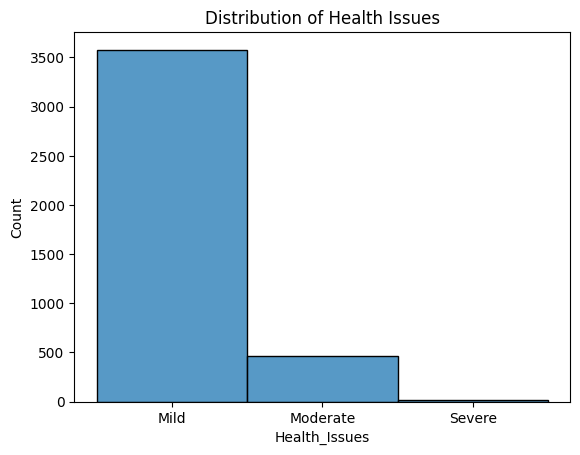

We notice that in this dataset most of the individuals do not consume alcohol supporting the idea and argument from TIME magazine, and amongst the one who does consume alcohol, there are more women consuming alcohol than men.

Consumption of alcohol is divided the next way:

> - 3485 women do not consume alcohol (34.85%)
> - 3354 men do not consume alcohol (33.54%)
> - 0.72% by Others

> - 1516 women consume alcohol (15.16%)
> - 1419 men consume alcohol (14.19%)
> - 1.54% by others

In general *69.11%*  of the individuals compounding this dataset does not consume alcohol meanwhile the other *29.89%* does.

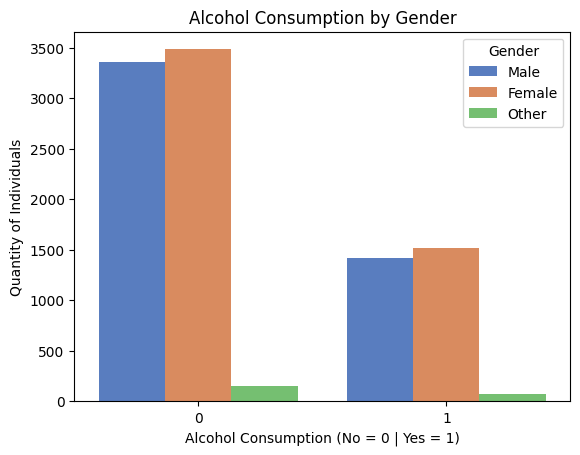

We notice similar patterns between the ones who consume alcohol and the ones who does not, wich may tell us that the alcohol consumption does not directly affects the stress levels or the sleep quality, but we will continue to analyze our data to conclude about this.

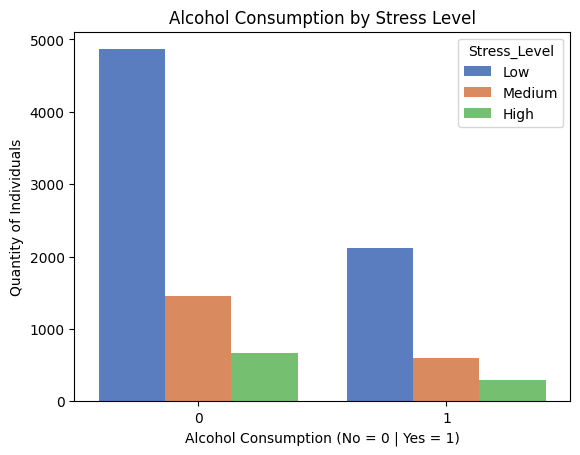

# Data Wrangling

For full Data Wrangling info see: notebooks/_02_data_wrangling.ipynb and scripts/preprocessing.py

The Data Wrangling consisted of 5 main steps:

1. Numeric Scaling: The numeric features that we worked on included many outliers, do to this scenario, the best scaler for this type of data is a robust scaler, which scales each instance based on the columns interquartile range. This helps the data avoid any type of skewness caused by the outliers. Robust scaler uses the formula: 
$$
X_\text{scaled} = \frac{x_i - Q_1(x)}{Q_3 - Q_1}
$$

2. Ordinal Encoding: This type of encoding consists of encoding variables based on the hierarchical placement. Few of our variables had this type of structure, thus ordinal encoding was up for the task.

3. One-Hot Encoding: Other variables had no hierarchical order, thus One-Hot Encoding was the best approach for this task. One-Hot creates a binary column for each category of the orignal column, marking 1 when an instance includes that category and 0 when it doesn't.

4. Country grouping by continents: In the country variable, many countries existed, thus the approach we decided to encapsulate each country belonging to its continent and then create a one-hot column for each contient.

5. Last but not least we did a class balancing using SMOTENC, with this we passed from: 

'Good': 4509, 'Fair': 1640, 'Excellent': 1082, 'Poor': 769

to:

'Good': 4509, 'Fair': 4509, 'Excellent': 4509, 'Poor': 4509


After, all changes were encapsulated on a column transformer which sequentially does all the transformations without the need to run every cell. The processed data was loaded to "data/processed/processed_coffee_data.csv".

All of this process was then put together in scripts/prepocessing.py.

In that script all the transformations needed for the proper functionality of the following model trainings is packed.

After applying transformations and droping variables, the correlation matrix of our data looked something like this.

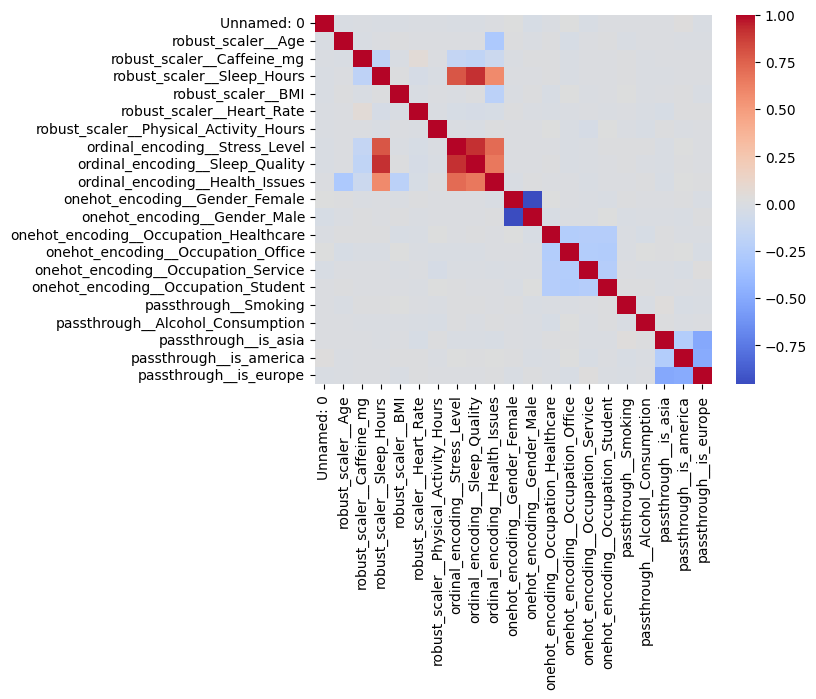

See the processed at data/processed/processed_coffe_data.csv

# Model Registry and Training

Model registry was made using MLFlow + Databricks to host the experiments, metrics and artifacts.

We made 3 different models, all of them tunned then using Optuna:

- MultiLayerPerceptron 
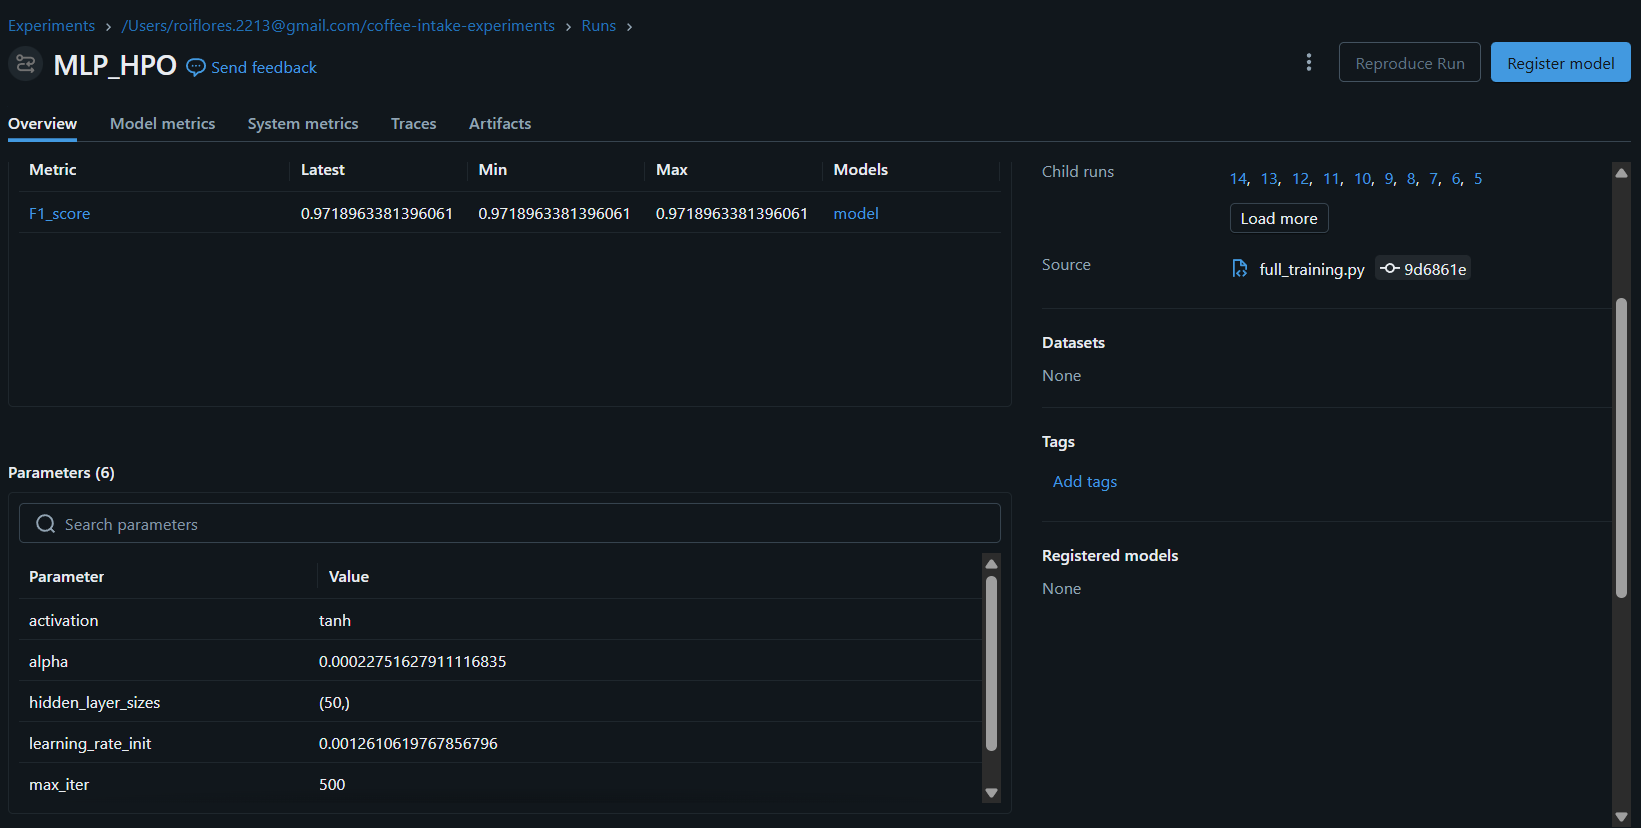
- LogisticRegression (Challenger)
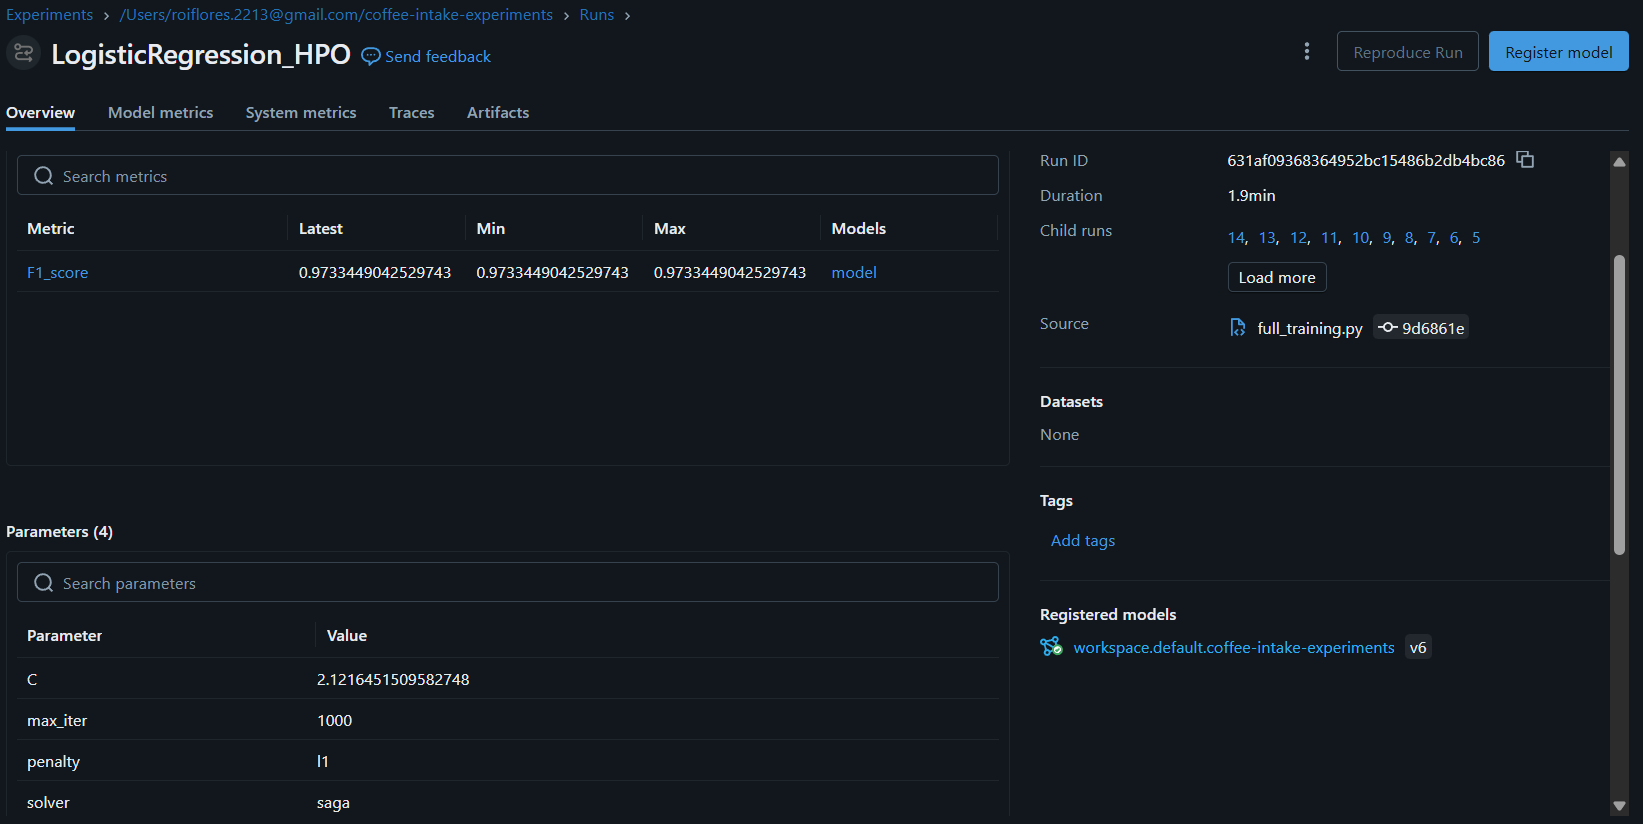
- RandomForest (Champion)
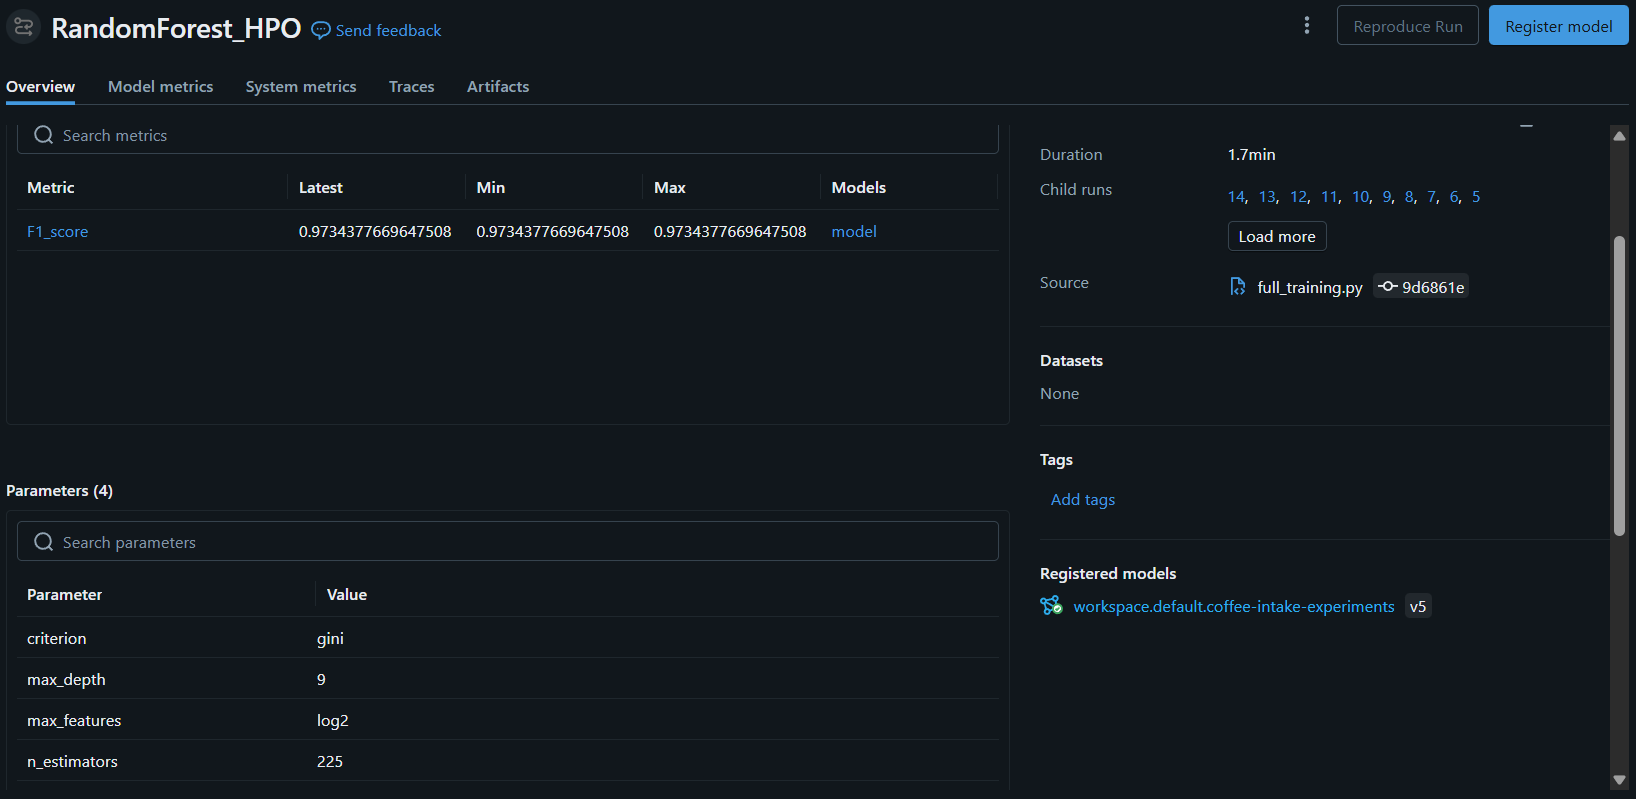

The 3 models were trained on a 80/20 train test split distribution, using Optuna for Fine Tunning, Cross Validation (to prevent overfitting) for best model selection from the runs and setting F1-Score as our Key Metric to compare the performance of the models, remember, F1-Score gives us a more robust value because it measures both False Positves and False Negatives, using the formula: $$ F1 = \frac{(2)(Precission)(Recall)}{(Precission)(Recall)}  $$

Using Prefect for the whole training process we stablished 4 tasks executed on a flow.

1. Load Data, loads the dataframe
2. Split Data, Train Test split and Target Separation
3. Run HPO, Select the best hyperparameters for each model
4. Register and Promote Models, Register the best model packed as a whole preprocessing + model pipeline very util to ensure reproducibility.

With the flow: Training Pipeline, here we orchestrate everything.

See src/pipeline/full_training.py for complete training process info.

See src/pipeline/optuna_utils.py for complete hyperparameters tunning info.

# Training Pipeline

See src/pipeline/... for full information about the pipeline.

The training pipeline is a key element of the Orchestration of our MLOps project and it consists of 3 principal files:

- src/pipeline/preprocessing.py

Here we apply all the changes to our data with the Classes Data_Wrangler, Column_Dropper and Column_Transformer, first step on the pipeline.

- src/pipeline/optuna_utils.py

Here we stablish the grid for the Hyperparameters tunning.

- src/pipeline/full_training.py

Here we run each experiment with 15 childs to pick the best model based on the F1-Score.

# FastAPI

See src/backend/api.py for full info about FastApi implementation and requirements.

We stablished the InputData class that will work as a JSON dictionary that the model will work with in order to predict, this is the basically the Goal Line of our pipeline.

A predict function that works using the champion model.

And a POST method that uses the dictionary to deliver the prediction to the user.

# Streamlit

See src/frontend/main.py for full info about Streamlit implementation and requirements.

This step is key to develop and interface that the final non-technic user will work with, Streamlit works as the Frontend our project, in charge of collect the user input data and provide a visualization of the results.

The app was created to offer usability and real time data validation, it asks the user to introduce the 12 variables that the model work with to predict his or her sleep quality based on them, using the Champion model, that in this case is, RandomForest.

One of the data transformations we applied here, is the estimation of the caffeine intake based on an average of 95mg per cup.

The app does not load the model directly but it access to it through a HTTP port with a POST petition from FastAPI, when the user press "Predecir" the app collects the inputs and constructs a JSON dictionary with an ID: 0 that is required by the pydantic schema.

# Docker

One of the last steps in our project was to migrate the whole working process to a container in Docker to ensure reproducibility anywhere and not just in a Local Machine.  Docker allows to isolate the required execution environment for the MLOps project.

Our implementation consist of two main Dockerfiles, one for the backend and one for the frontend.

- Backend Dockerfile (coffee_api)

This Dockerfile isolates the API logic developed with FastAPI, we set to expose port 8000 and receive sensitive credentials from the .env (ignored) in the following format:

DATABRICKS_TOKEN= ...
DATABRICKS_HOST= ...

- Frontend Dockerfile (coffee_ui)

This Dockerfile contains the user interface from Streamlit, we set to expose the port 8501 to access through Internet and it's constructed on an independent way to prevent interfering with model dependencies.

### Docker Compose Orchestration

The simultaneous execution of both containers is thanks to docker.compose.yaml.

- Private Network (coffee_network)

We created a bridge type network that allows the containers to communicate on a safe manner.

- Service Discovery

Thanks to the stablished private network, Frontend does not need to recognize the IP from the API, instead we set the variable:

API_URL=http://api:8000/api/v1/predict

Utilizing the name of the service as hostname. Docker recognizes this name and stablishes a safe connection between interface and model.

Thanks to this implementation, to set up the project in a new location we just need to execute the following command:

docker-compose up --build

And we are ready to predict!

# Huggingface

https://huggingface.co/spaces/perroi13/Coffee_Intake_UI

As the very final step of the MLOps flow we choose to deploy our user interface in a public cloud environment, Huggingface Spaces, it allows remote access and validation from users without any installation requirements.

Huggingface is compatible with Docker and guarantees the dependencies to be identical as the ones stablished on the development environment.

The result is a fully functional web application accessible from any browser. Users can interact with the predictive model, enter their coffee consumption and health data to receive real-time predictions.

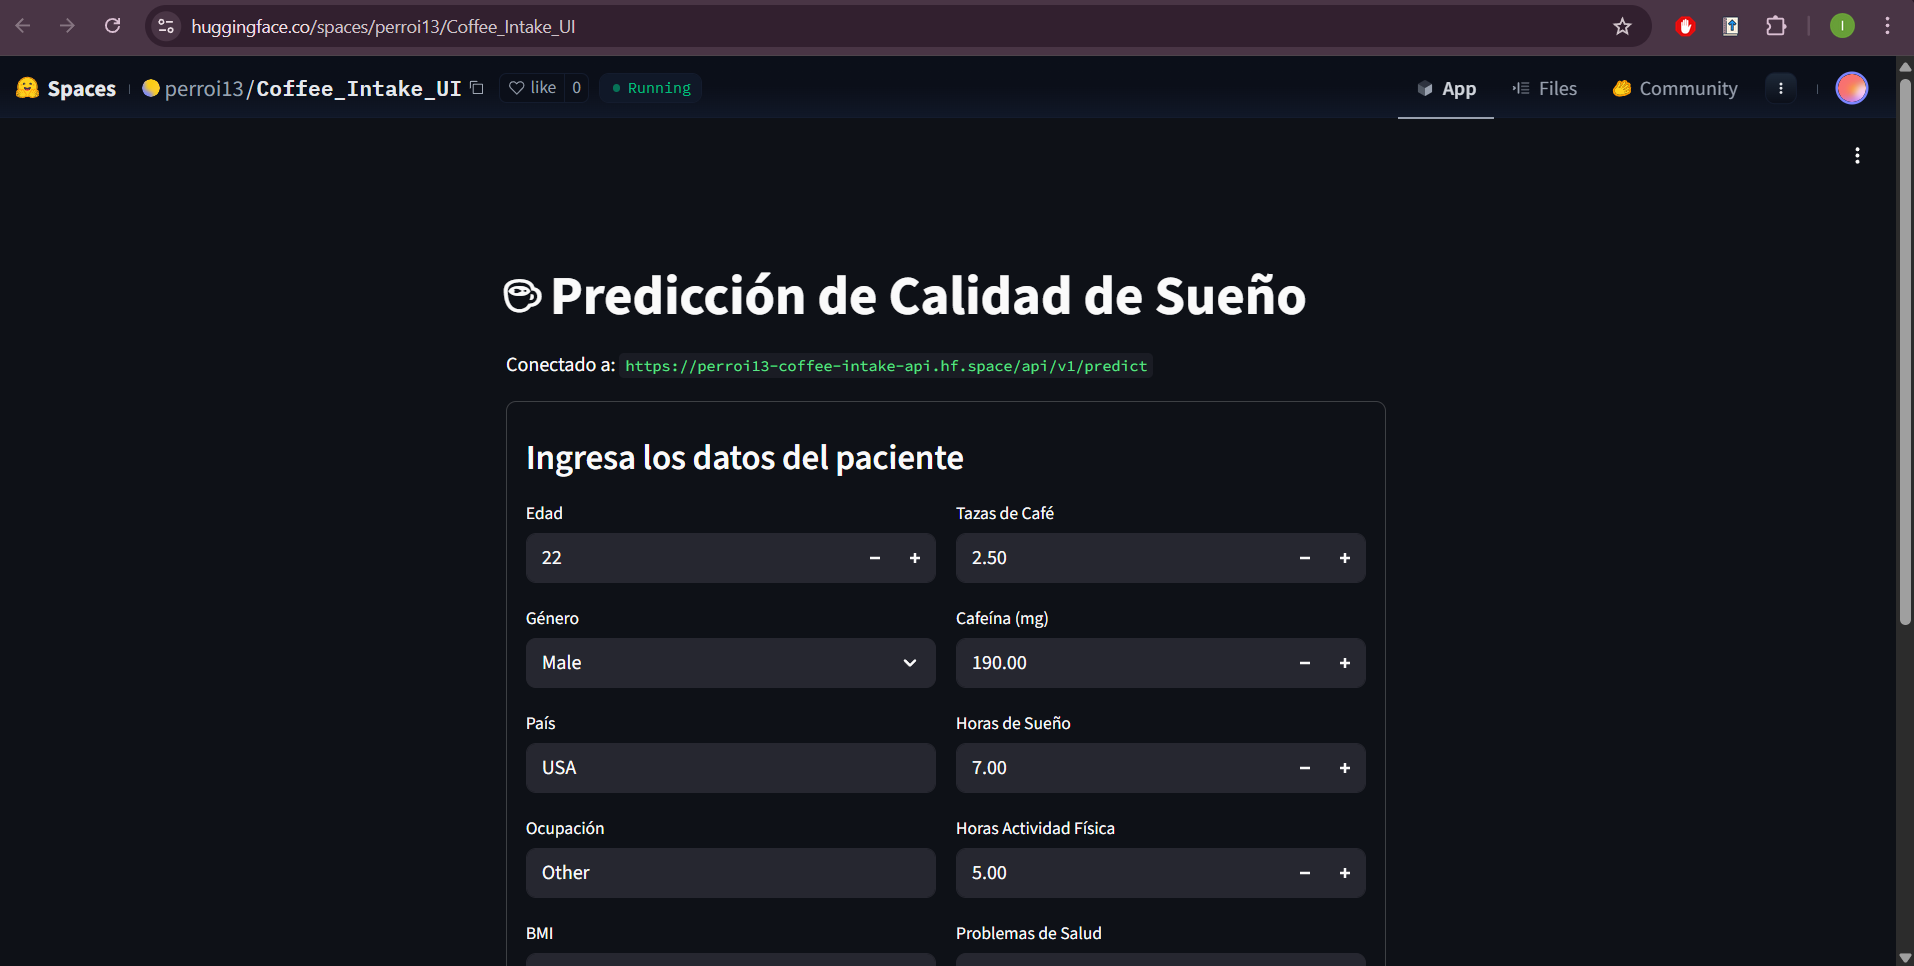

# Conclusions

The execution of a data science project is undoubtedly taken to the next level when it adheres to the guidelines and requirements established by MLOps. Without a doubt, the development of this project was a challenge from beginning to end, involving sweat, tears, computer restarts, version conflicts, and other setbacks that represent what constantly happens in a production environment.

As data science engineers, it is necessary to know how to collaborate in a team using tools such as GitHub, Docker, Huggingface, Databricks, and Mlflow. Understanding the use of this set of tools will allow us to excel in the job market once we graduate.

In conclusion, regarding the data and the model, we encountered a limitation due to an erroneous interpretation of the Sleep_Hours variable. This variable should have been eliminated from the outset to build a more robust model. In the real world, this variable is undoubtedly important for defining the sleep quality of any patient and is affected by all the factors included in the dataset. However, the nature of our data is synthetic, and it is clear that at the time of data collection, sleep quality was directly affected by sleep duration, as can be seen in the EDA graphs, and is distributed as follows:

- Poor, 3-5 hours

- Fair, 5-6 hours

- Good, 6-8 hours

- Excellent, 8-10 hours

The model is very sensitive to this variable and does not allow us to observe the true influence of the other variables.

In general we are very satisfied with how the project was developed and how it was deployed on Hugginface, but its predictive power can definitely be improved.

Thanks ZapataCC!

Roi, Ivan.

# References
 
 - Global Coffee Health Dataset from Laksika Tharmalingam, https://www.kaggle.com/datasets/uom190346a/global-coffee-health-dataset/data
 - 2 easy, accurate ways to measure your heart rate. (2025). Mayo Clinic. https://www.mayoclinic.org/healthy-lifestyle/fitness/expert-answers/heart-rate/faq-20057979#:~:text=A%20normal%20resting%20heart%20rate%20for%20adults%20ranges%20from%2060,to%2040%20beats%20per%20minute.
 - Are there more men or more women in the world? (2020). Ined - Institut National d’Études Démographiques. https://www.ined.fr/en/everything_about_population/demographic-facts-sheets/faq/more-men-or-women-in-the-world/
 - Arslan, S., Kevser TARI Selcuk, Kübra Betül Kirbiyik, & Nuh Şerbetçi̇. (2025). The relationship between caffeine consumption and self-reported sleep quality among healthcare professionals. Advances in Integrative Medicine, 12(4), 100553–100553. https://doi.org/10.1016/j.aimed.2025.100553
 - Burga, S. (2025). Why Gen Z Is Drinking Less. TIME; Time. https://time.com/7203140/gen-z-drinking-less-alcohol/

‌

‌

‌